In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Load dataset + Normalization

In [11]:
# --- Load Dataset ---
file_path = os.path.join("data", "MindShield_Dataset_9.xlsx")
df = pd.read_excel(file_path)

print("Loaded", df.shape)
print("Columns:", df.columns.tolist())

# --- Normalization (your main one) ---
def normalize_sinhala_singlish_v2(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFKC", text.lower())

    SINGLISH_VARIANTS = [
        (r"\b(marenne|maranne|marenawa|merenna)\b", "marenna"),
        (r"\b(jeewithe\s*epa|jeewithe\s*epawela)\b", "jeewithe_epa"),
        (r"\b(siyadiwi\s*nasaganna)\b", "siyadiwi_nasaganna"),
        (r"\b(me\s*loken\s*yanna|loken\s*yanna)\b", "loken_yanna"),
        (r"\b(waha\s*kanna)\b", "waha_kanna"),
        (r"\b(jeewath\s*wenna\s*baa|jeewath\s*wenna\s*ba)\b", "jeewath_wenna_baha"),
        (r"\b(daraganna\s*baa|daraganna\s*ba)\b", "daraganna_baha"),
        (r"\b(manasika\s*peedanaya|manasikawa\s*watila)\b", "manasika_peedanaya"),
        (r"\b(papuwa\s*ridenawa|hadawatha\s*ridenawa)\b", "papuwa_ridenawa"),
        (r"\b(waira\s*karanawa)\b", "waira_karanawa"),
        (r"\b(puduma\s*dukak|pudumai\s*dukak|poduma\s*dukak)\b", "puduma_dukak"),
        (r"\b(mage\s*hitha\s*ridena(wa)?|hitha\s*ridena(wa)?)\b", "hitha_ridenawa"),
    ]

    SINHALA_VARIANTS = [
        (r"(මැරෙන්න|මැරෙනවා|මරන්න|මැරුණා)", "මැරෙන්න"),
        (r"ජීවිතේ\s*එපා", "ජීවිතේ_එපා"),
        (r"ජීවිතේම\s*එපා\s*වෙලා", "ජීවිතේ_එපා"),
        (r"සියදිවි\s*නසාගන්න", "සියදිවි_නසාගන්න"),
        (r"ලෝකෙන්\s*යන්න", "ලෝකෙන්_යන්න"),
        (r"වහ\s*කන්න", "වහ_කන්න"),
        (r"වහ\s*කනවා", "වහ_කන්න"),
        (r"ජීවත්\s*වෙන්න\s*බෑ", "ජීවත්_වෙන්න_බෑ"),
        (r"දරාගන්න\s*බෑ", "දරාගන්න_බෑ"),
        (r"දරාගන්න\s*අමාරුයි", "දරාගන්න_බෑ"),
        (r"මානසික\s*පීඩනය", "මානසික_පීඩනය"),
        (r"මානසික\s*පීඩනේක\s*ඉන්නේ", "මානසික_පීඩනය"),
        (r"පීඩනේක\s*ඉන්නේ", "මානසික_පීඩනය"),
        (r"ඔලුව\s*විකාරයි", "ඔලුව_විකාරයි"),
        (r"පපුව\s*රිදෙනවා", "පපුව_රිදෙනවා"),
        (r"හදවත\s*රිදෙනවා", "හදවත_රිදෙනවා"),
        (r"වෛර\s*කරනවා", "වෛර_කරනවා"),
        (r"පුදුම\s*දුකක්", "පුදුම_දුකක්"),
        (r"හිත\s*රිදෙනවා", "හිත_රිදෙනවා"),
    ]

    for pattern, standard in SINGLISH_VARIANTS:
        text = re.sub(pattern, standard, text, flags=re.IGNORECASE)

    for pattern, standard in SINHALA_VARIANTS:
        text = re.sub(pattern, standard, text)

    STOPWORDS = {
        'mama','mage','mata','mawa','api','ape','apiwa','oya','oyage','oba','obage','eya','eyage',
        'eka','eyala','meka','uba','ubage','ohu','man','mam','mn','mt','mge','e',
        'මම','මට','මගේ','මාව','අපි','අපේ','ඔබ','ඔයා','එයා','එක','මේක',
        'mokakda','mokada','kawda','kohomada','kara','karanawa','gena','wena',
        'nisa','eth','saha','da','namuth','ane','wage','kiyala','ekka',
        'dan','ai','one','thamai','dn','oni','unath','hinda','ona',
        'නිසා','එත්','සහ','ද','නමුත්','දැන්','වගේ','කියලා','එක්ක','ඕනේ',
    }

    words = [w for w in text.split() if w not in STOPWORDS]
    text = " ".join(words)

    SINGLISH_RULES = [
        (r"\b(ba|baa+|baha)\b", "baha"),
        (r"\b(epa|epaa+)\b", "epa"),
        (r"\b(na|naa)\b", "na"),
        (r"\b(duka|duki)\b", "duka"),
        (r"\b(dukai+|dukak)\b", "dukak"),
        (r"\b(wedana[a-z]*)\b", "wedanawa"),
        (r"\b(riden[a-z]*)\b", "ridenawa"),
        (r"\b(thani[a-z]*)\b", "thani"),
        (r"\b(thanikama[a-z]*)\b", "thanikama"),
        (r"\b(hithenawa|hithenav[a-z]*)\b", "hithenawa"),
        (r"\b(bari|beri)\b", "bari"),
    ]

    SINHALA_RULES = [
        (r"(බෑ|බැ|බැහැ)", "බැහැ"),
        (r"එපා+", "එපා"),
        (r"දුකයි", "දුක"),
        (r"තනියෙන්", "තනි"),
        (r"\bනෙමෙයි\b", "නෙවෙයි"),
        (r"\bමොකක්ද\b", "මොකද්ද"),
        (r"\bකොහොමද\b", "කොහොම"),
    ]

    for pattern, repl in SINGLISH_RULES:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)

    for pattern, repl in SINHALA_RULES:
        text = re.sub(pattern, repl, text)

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"([\U00010000-\U0010ffff])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply
df["clean_text"] = df["Text"].apply(normalize_sinhala_singlish_v2)
print("Enhanced normalization complete")

df[["Text", "clean_text"]].head()


Loaded (5000, 2)
Columns: ['Text', 'Risk_Level']
Enhanced normalization complete


,Text,clean_text
0,eya awilla mata duka witharak ithuru karala ya...,awilla duka witharak ithuru karala yanawa
1,dan masaa hatharak wenawa daala gihin amathaka...,masaa hatharak wenawa daala gihin amathaka kar...
2,Daala yanna nam sathekutawath adare karanna ep...,daala yanna nam sathekutawath adare karanna ep...
3,Aluthen jeewitheta ena hama kenama magak awith...,aluthen jeewitheta ena hama kenama magak awith...
4,Pana wage adarei kiyala lan wela hitiyata koi ...,pana adarei lan wela hitiyata koi mohote hari ...


# Encode labels + Split + TF-IDF

In [ ]:
# --- Label encoding ---
label_col = "Risk_Level" 
le = LabelEncoder()
df["label"] = le.fit_transform(df[label_col].astype(str))
class_names = list(le.classes_)

# --- Split ---
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- TF-IDF ---
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Split + TF-IDF done")


Split + TF-IDF done


# Training 6 techniques

In [13]:
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": MultinomialNB(),
    "SVM (SVC)": SVC(kernel="linear"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=50),
}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"DETAILED REPORT FOR: {name}")
    print("="*60)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1 (macro):", round(f1_score(y_test, y_pred, average="macro"), 4))
    print("\n" + classification_report(y_test, y_pred, target_names=class_names, digits=2, zero_division=0))



DETAILED REPORT FOR: Logistic Regression
Accuracy: 0.648
F1 (macro): 0.6503

              precision    recall  f1-score   support

   High Risk       0.66      0.70      0.68       316
 Medium Risk       0.57      0.65      0.61       346
     No Risk       0.75      0.59      0.66       338

    accuracy                           0.65      1000
   macro avg       0.66      0.65      0.65      1000
weighted avg       0.66      0.65      0.65      1000


DETAILED REPORT FOR: Naive Bayes
Accuracy: 0.625
F1 (macro): 0.6242

              precision    recall  f1-score   support

   High Risk       0.67      0.70      0.69       316
 Medium Risk       0.51      0.73      0.60       346
     No Risk       0.86      0.44      0.58       338

    accuracy                           0.62      1000
   macro avg       0.68      0.63      0.62      1000
weighted avg       0.68      0.62      0.62      1000


DETAILED REPORT FOR: SVM (SVC)
Accuracy: 0.653
F1 (macro): 0.6548

              precisio

In [14]:
results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    rep = classification_report(
        y_test, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Macro": rep["macro avg"]["precision"],
        "Recall_Macro": rep["macro avg"]["recall"],
        "F1_Macro": rep["macro avg"]["f1-score"],
        "Precision_Weighted": rep["weighted avg"]["precision"],
        "Recall_Weighted": rep["weighted avg"]["recall"],
        "F1_Weighted": rep["weighted avg"]["f1-score"],
    })

comparison_df = pd.DataFrame(results).sort_values("F1_Macro", ascending=False)

# show nicely rounded
comparison_df.round(3)


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted
2,SVM (SVC),0.653,0.670,0.655,0.655,0.669,0.653,0.653
0,Logistic Regression,0.648,0.661,0.649,0.650,0.660,0.648,0.649
1,Naive Bayes,0.625,0.681,0.626,0.624,0.680,0.625,0.623
3,Random Forest,0.616,0.618,0.619,0.615,0.618,0.616,0.614
5,Decision Tree,0.536,0.542,0.538,0.525,0.542,0.536,0.523
4,KNN,0.347,0.398,0.354,0.285,0.400,0.347,0.280


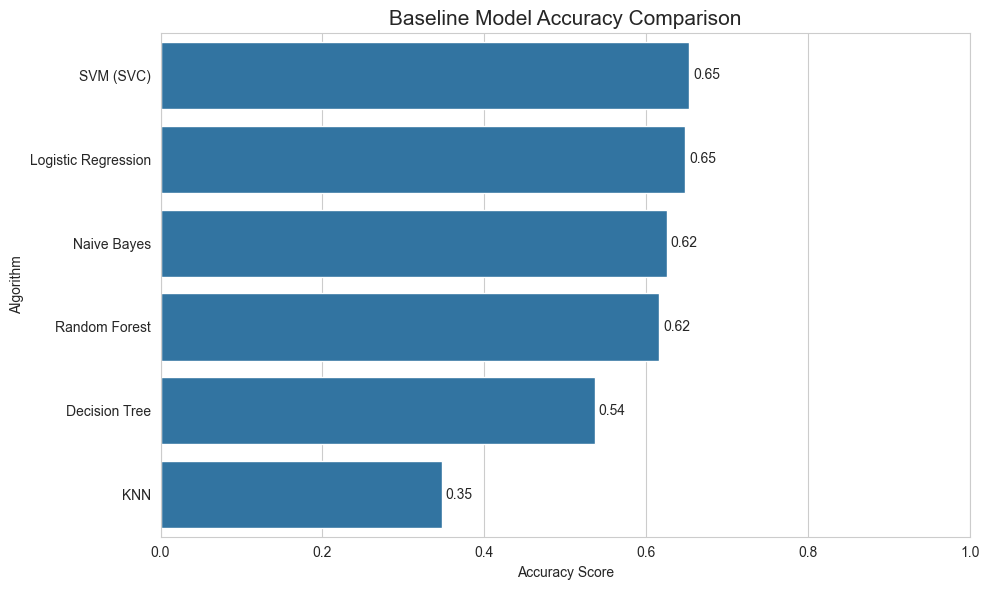

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Accuracy', y='Model', data=comparison_df)

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)

plt.title('Baseline Model Accuracy Comparison', fontsize=15)
plt.xlim(0, 1.0)
plt.xlabel('Accuracy Score')
plt.ylabel('Algorithm')
plt.tight_layout()
plt.show()
